In [2]:
# Customer Segmentation Analysis

In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

In [4]:
df = pd.read_excel("../data/raw/Online Retail.xlsx")

In [5]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
df.shape

(541909, 8)

In [7]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [8]:
df["CustomerID"].isna().sum()

np.int64(135080)

In [9]:
df = df.dropna(subset=["CustomerID"]).copy()

In [10]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

df[["CustomerID", "Quantity", "UnitPrice", "Revenue"]].head()


,CustomerID,Quantity,UnitPrice,Revenue
0,17850.0,6,2.55,15.30
1,17850.0,6,3.39,20.34
2,17850.0,8,2.75,22.00
3,17850.0,6,3.39,20.34
4,17850.0,6,3.39,20.34


In [11]:
df = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0) &
    (~df["InvoiceNo"].astype(str).str.startswith("C"))
].copy()

print(df.shape)

(397884, 9)


In [12]:
df[["InvoiceNo", "CustomerID", "InvoiceDate", "Quantity", "UnitPrice", "Revenue"]].head()

,InvoiceNo,CustomerID,InvoiceDate,Quantity,UnitPrice,Revenue
0,536365,17850.0,2010-12-01 08:26:00,6,2.55,15.30
1,536365,17850.0,2010-12-01 08:26:00,6,3.39,20.34
2,536365,17850.0,2010-12-01 08:26:00,8,2.75,22.00
3,536365,17850.0,2010-12-01 08:26:00,6,3.39,20.34
4,536365,17850.0,2010-12-01 08:26:00,6,3.39,20.34


In [13]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print(reference_date)

2011-12-10 12:50:00


In [14]:
rfm = df.groupby("CustomerID").agg(
    Recency = ("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency = ("InvoiceNo", "nunique"),
    Monetary = ("Revenue", "sum")
)

rfm.colums = ["Recency", "Frequency", "Monetary"]

rfm.head()

C:\Users\Seyma\AppData\Local\Temp\ipykernel_10804\1351730574.py:7: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  rfm.colums = ["Recency", "Frequency", "Monetary"]


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [15]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]    
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
CustomerID,,,,,,
12346.0,326,1,77183.60,1,1,5
12347.0,2,7,4310.00,5,5,5
12348.0,75,4,1797.24,2,4,4
12349.0,19,1,1757.55,4,1,4
12350.0,310,1,334.40,1,1,2


In [16]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(int) +
    rfm["F_Score"].astype(int) +
    rfm["M_Score"].astype(int)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,5,7
12347.0,2,7,4310.00,5,5,5,15
12348.0,75,4,1797.24,2,4,4,10
12349.0,19,1,1757.55,4,1,4,9
12350.0,310,1,334.40,1,1,2,4


In [17]:
def segment_customer(score):
    if score >= 13:
        return "Champions"
    elif score >= 10:
        return "Loyal Customers"
    elif score>= 7:
        return "Potential Loyalists"
    elif score>= 5:
        return "At Risk"
    else: 
        return "Hibernating"
    

rfm["Segment"] = rfm["RFM_Score"].apply(segment_customer)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,5,7,Potential Loyalists
12347.0,2,7,4310.00,5,5,5,15,Champions
12348.0,75,4,1797.24,2,4,4,10,Loyal Customers
12349.0,19,1,1757.55,4,1,4,9,Potential Loyalists
12350.0,310,1,334.40,1,1,2,4,Hibernating


In [18]:
rfm["Segment"].value_counts()

Segment
Potential Loyalists    1089
Loyal Customers        1010
Champions               930
At Risk                 761
Hibernating             548
Name: count, dtype: int64

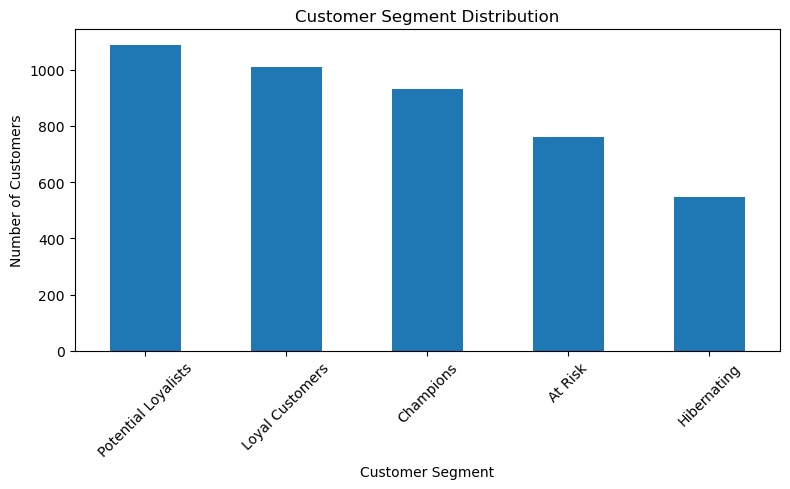

In [19]:
segment_customer = rfm["Segment"].value_counts()

plt.figure(figsize=(8,5))
segment_customer.plot(kind="bar")

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
segment_revenue = rfm.groupby("Segment")["Monetary"].mean().sort_values(ascending=False)

segment_revenue

Segment
Champions              6713.001075
Loyal Customers        1404.170120
Potential Loyalists     810.973023
At Risk                 343.642078
Hibernating             192.415766
Name: Monetary, dtype: float64

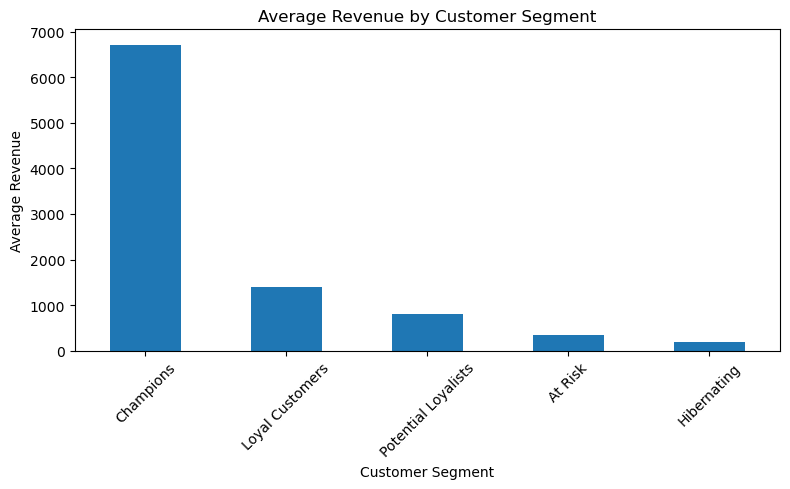

In [21]:
plt.figure(figsize=(8,5))

segment_revenue.plot(kind="bar")

plt.title("Average Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
segment_behavior = rfm.groupby("Segment")[[
    "Recency",
    "Frequency",
    "Monetary"
]].mean()

segment_behavior

,Recency,Frequency,Monetary
Segment,,,
At Risk,146.972405,1.228647,343.642078
Champions,14.493548,11.766667,6713.001075
Hibernating,254.125912,1.009124,192.415766
Loyal Customers,43.361386,3.869307,1404.170120
Potential Loyalists,85.438017,2.013774,810.973023


In [24]:
"""
Customer Segmentation Results :

The RFM (Recency, Frequency, Monetary) analysis was used to segment customers according to their purchasing behavior.
The customers were divided into five segments based on their RFM scores:

- **Champions:** Customers who purchase recently, frequently, and generate high revenue.
- **Loyal Customers:** Customers who show regular purchasing behavior and contribute consistent revenue.
- **Potential Loyalists:** Customers with potential to become more loyal through targeted marketing strategies.
- **At Risk:** Customers who have not purchased recently and may be at risk of being lost.
- **Hibernating:** Customers who have been inactive for a long time and generate relatively low revenue.

The analysis showed that Champions had the highest average frequency and monetary value, while Hibernating customers had the lowest engagement and spending levels.
These results can be used to develop targeted marketing strategies for different customer groups and can later be integrated into the project dashboard.


#####

RFM (Recency, Frequency, Monetary) analizi, müşterileri satın alma davranışlarına göre segmentlere ayırmak için kullanılmıştır.
Müşteriler RFM skorlarına göre beş segmente ayrılmıştır:

- **Champions:** Yakın zamanda ve sık alışveriş yapan, yüksek gelir sağlayan müşteriler.
- **Loyal Customers:** Düzenli satın alma davranışı gösteren ve istikrarlı gelir sağlayan müşteriler.
- **Potential Loyalists:** Doğru pazarlama stratejileriyle daha sadık müşterilere dönüşme potansiyeli bulunan müşteriler.
- **At Risk:** Uzun süredir alışveriş yapmayan ve kaybedilme riski bulunan müşteriler.
- **Hibernating:** Uzun süredir aktif olmayan ve görece düşük gelir sağlayan müşteriler.

Analiz sonucunda Champions segmentinin ortalama alışveriş sıklığı ve harcama değerinin en yüksek olduğu, Hibernating segmentinin ise en düşük etkileşim ve harcama seviyelerine sahip olduğu görülmüştür.
Bu sonuçlar, farklı müşteri gruplarına yönelik hedefli pazarlama stratejileri geliştirmek ve daha sonra proje dashboard'una entegre etmek için kullanılabilir.

 
"""

"\nCustomer Segmentation Results :\n\nThe RFM (Recency, Frequency, Monetary) analysis was used to segment customers according to their purchasing behavior.\nThe customers were divided into five segments based on their RFM scores:\n\n- **Champions:** Customers who purchase recently, frequently, and generate high revenue.\n- **Loyal Customers:** Customers who show regular purchasing behavior and contribute consistent revenue.\n- **Potential Loyalists:** Customers with potential to become more loyal through targeted marketing strategies.\n- **At Risk:** Customers who have not purchased recently and may be at risk of being lost.\n- **Hibernating:** Customers who have been inactive for a long time and generate relatively low revenue.\n\nThe analysis showed that Champions had the highest average frequency and monetary value, while Hibernating customers had the lowest engagement and spending levels.\nThese results can be used to develop targeted marketing strategies for different customer gro

In [26]:
segment_summary = rfm.groupby("Segment").agg(
    Customer_Count=("Segment", "size"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).sort_values("Customer_Count", ascending=False)

segment_summary

,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
Potential Loyalists,1089,85.438017,2.013774,810.973023
Loyal Customers,1010,43.361386,3.869307,1404.170120
Champions,930,14.493548,11.766667,6713.001075
At Risk,761,146.972405,1.228647,343.642078
Hibernating,548,254.125912,1.009124,192.415766
